In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
emma_data = pd.read_csv('../data/FullData.txt', sep='\t')

In [82]:
emma_data.head()

,Order,Family,Strand,Species,-,A,C,D,E,F,...,N,P,Q,R,S,T,V,Y,W,X
Alphaflexiviridae_u17540|Narcissus,Tymovirales,Alphaflexiviridae,positive,u17540|Narcissus,230,12,1,8,5,7,...,5,2,4,2,3,8,2,4,0,0
Alphaflexiviridae_u17602,Tymovirales,Alphaflexiviridae,positive,u17602,230,9,1,8,5,6,...,4,3,5,2,5,7,4,4,1,0
Alphaflexiviridae_u4329|Lily,Tymovirales,Alphaflexiviridae,positive,u4329|Lily,230,11,2,7,5,5,...,3,3,7,1,4,7,2,4,0,0
Alphaflexiviridae_u6633|Papaya,Tymovirales,Alphaflexiviridae,positive,u6633|Papaya,230,11,1,8,5,7,...,4,3,4,1,4,9,2,2,0,0
Alphaflexiviridae_u11143,Tymovirales,Alphaflexiviridae,positive,u11143,230,10,1,8,6,9,...,5,3,4,2,3,7,5,4,0,0


In [83]:
emma_data['Strand'].unique()

array(['positive ', 'double', 'negative'], dtype=object)

In [84]:
aa_mapping = {
    "A": "Ala",
    "C": "Cys",
    "D": "Asp",
    "E": "Glu",
    "F": "Phe",
    "G": "Gly",
    "H": "His",
    "I": "Ile",
    "K": "Lys",
    "L": "Leu",
    "M": "Met",
    "N": "Asn",
    "P": "Pro",
    "Q": "Gln",
    "R": "Arg",
    "S": "Ser",
    "T": "Thr",
    "V": "Val",
    "W": "Trp",
    "Y": "Tyr",
    "X": "Xaa"   # неизвестная/неопределённая аминокислота
}

# 1. Исправляем перепутанные названия Order и Family
emma_data = emma_data.rename(columns={
    "Order": "Family",
    "Family": "Order"
})

# 2. Находим реально присутствующие аминокислотные колонки
aa_columns = [aa for aa in aa_mapping if aa in emma_data.columns]

# 3. Добавляем длину последовательности
# Считаем все аминокислоты, включая X
emma_data["Length"] = emma_data[aa_columns].sum(axis=1)

# 4. Переименовываем аминокислотные колонки
emma_data = emma_data.rename(columns=aa_mapping)

# 5. Заменяем обозначения типа генома
strand_mapping = {
    "positive": "ssRNA+",
    "negative": "ssRNA-",
    "double": "dsRNA"
}

emma_data["Strand"] = (
    emma_data["Strand"]
    .astype(str)
    .str.strip()
    .replace(strand_mapping)
)

In [85]:
emma_data

,Family,Order,Strand,Species,-,Ala,Cys,Asp,Glu,Phe,...,Pro,Gln,Arg,Ser,Thr,Val,Tyr,Trp,Xaa,Length
Alphaflexiviridae_u17540|Narcissus,Tymovirales,Alphaflexiviridae,ssRNA+,u17540|Narcissus,230,12,1,8,5,7,...,2,4,2,3,8,2,4,0,0,95
Alphaflexiviridae_u17602,Tymovirales,Alphaflexiviridae,ssRNA+,u17602,230,9,1,8,5,6,...,3,5,2,5,7,4,4,1,0,95
Alphaflexiviridae_u4329|Lily,Tymovirales,Alphaflexiviridae,ssRNA+,u4329|Lily,230,11,2,7,5,5,...,3,7,1,4,7,2,4,0,0,95
Alphaflexiviridae_u6633|Papaya,Tymovirales,Alphaflexiviridae,ssRNA+,u6633|Papaya,230,11,1,8,5,7,...,3,4,1,4,9,2,2,0,0,95
Alphaflexiviridae_u11143,Tymovirales,Alphaflexiviridae,ssRNA+,u11143,230,10,1,8,6,9,...,3,4,2,3,7,5,4,0,0,95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Yueviridae_u162948,Goujianvirales,Yueviridae,ssRNA-,u162948,45,3,1,6,7,8,...,1,1,5,11,5,6,4,2,0,101
Yueviridae_u195939,Goujianvirales,Yueviridae,ssRNA-,u195939,61,8,1,6,3,10,...,1,2,4,10,3,2,0,1,0,85
Yueviridae_u242785,Goujianvirales,Yueviridae,ssRNA-,u242785,45,9,3,7,5,8,...,2,1,5,5,5,8,2,1,0,101
Yueviridae_u116278,Goujianvirales,Yueviridae,ssRNA-,u116278,45,3,0,8,8,12,...,1,1,2,8,8,8,0,2,0,101


In [86]:
aa_columns = [
    "Ala", "Cys", "Asp", "Glu", "Phe",
    "Gly", "His", "Ile", "Lys", "Leu",
    "Met", "Asn", "Pro", "Gln", "Arg",
    "Ser", "Thr", "Val", "Trp", "Tyr"
]

In [87]:
dataset_summary = pd.Series({
    "Number of sequences": len(emma_data),
    "Number of unique viruses/species": emma_data["Species"].nunique(),
    "Number of families": emma_data["Family"].nunique(),
    "Number of orders": emma_data["Order"].nunique()
})

dataset_summary

Number of sequences                 77208
Number of unique viruses/species    77208
Number of families                     24
Number of orders                       73
dtype: int64

In [88]:
summary_by_strand = (
    emma_data
    .groupby("Strand", observed=False)
    .agg(
        n_sequences=("Species", "size"),
        n_viruses=("Species", "nunique"),
        n_families=("Family", "nunique"),
        n_orders=("Order", "nunique"),
        median_length=("Length", "median"),
        mean_length=("Length", "mean"),
        min_length=("Length", "min"),
        max_length=("Length", "max")
    )
    .reset_index()
)

summary_by_strand.round(1)

,Strand,n_sequences,n_viruses,n_families,n_orders,median_length,mean_length,min_length,max_length
0,dsRNA,12589,12589,5,9,108.0,113.0,53,250
1,ssRNA+,60793,60793,14,43,103.0,102.9,52,238
2,ssRNA-,3826,3826,6,21,118.0,124.2,53,235


In [89]:
print("Полных дубликатов строк:", emma_data.duplicated().sum())
print(
    "Повторяющихся значений Species:",
    emma_data["Species"].duplicated().sum()
)

Полных дубликатов строк: 0
Повторяющихся значений Species: 0


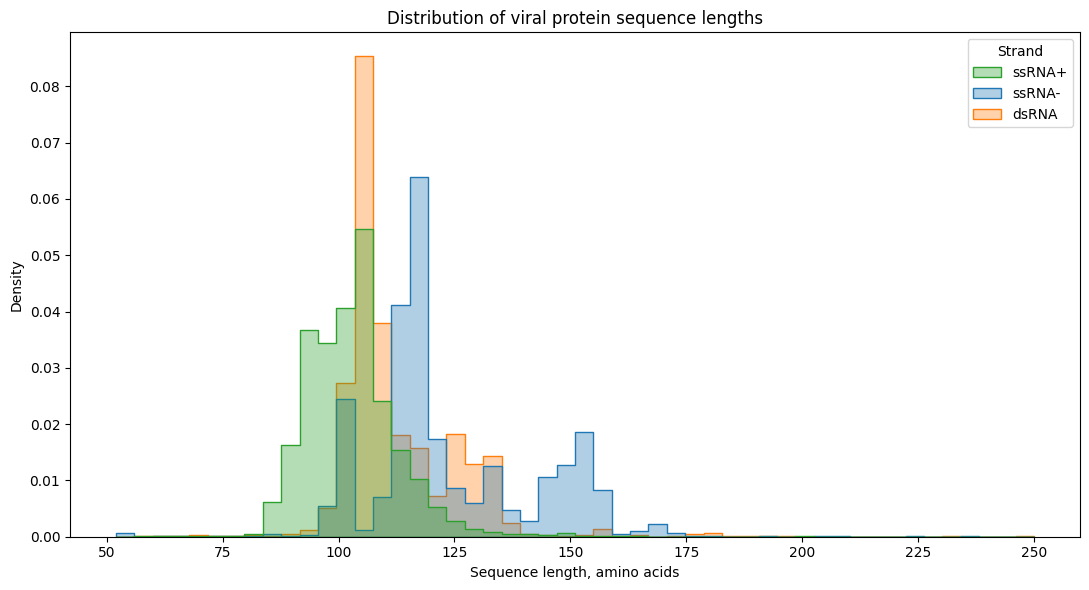

In [100]:
strand_palette = {
    "dsRNA": "tab:orange",
    "ssRNA+": "tab:green",
    "ssRNA-": "tab:blue"
}

strand_order = ["ssRNA+", "ssRNA-", "dsRNA"]

plt.figure(figsize=(11, 6))

sns.histplot(
    data=emma_data,
    x="Length",
    hue="Strand",
    hue_order=strand_order,
    palette=strand_palette,
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
    alpha=0.35
)

plt.xlabel("Sequence length, amino acids")
plt.ylabel("Density")
plt.title("Distribution of viral protein sequence lengths")
plt.tight_layout()
plt.savefig('../figures/emma_lengts_all.pdf')
plt.show()
plt.close()

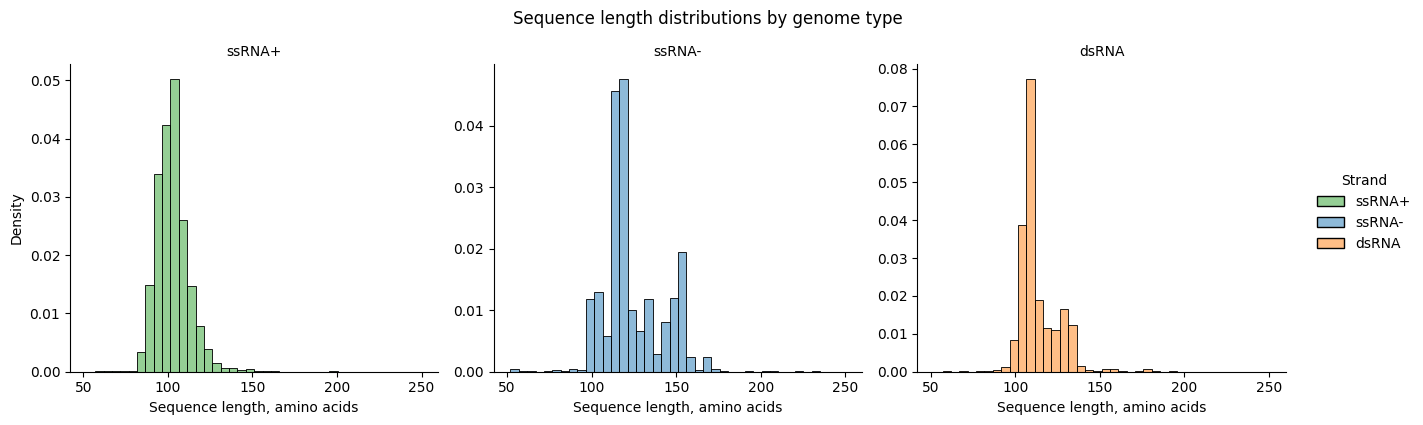

In [101]:
g = sns.displot(
    data=emma_data,
    x="Length",
    col="Strand",
    col_order=strand_order,
    hue="Strand",
    hue_order=strand_order,
    palette=strand_palette,
    bins=40,
    stat="density",
    common_norm=False,
    height=4,
    aspect=1.1,
    facet_kws={"sharey": False}
)

g.set_axis_labels(
    "Sequence length, amino acids",
    "Density"
)

g.set_titles("{col_name}")
g.figure.suptitle(
    "Sequence length distributions by genome type",
    y=1.05
)
plt.savefig('../figures/emma_lengts_all_separated.pdf')
plt.show()
plt.close()

In [92]:
family_counts = (
    emma_data
    .groupby("Family", dropna=False)["Species"]
    .nunique()
    .sort_values(ascending=False)
    .rename("Number_of_viruses")
    .reset_index()
)

family_counts.head(20)

,Family,Number_of_viruses
0,Levivirales,29108
1,Durnavirales,10187
2,Cryppavirales,8807
3,Picornavirales,7683
4,Ourlivirales,4647
5,Tolivirales,4090
6,Ghabrivirales,2514
7,Mononegavirales,1644
8,Martellivirales,1641
9,Nodamuvirales,1327


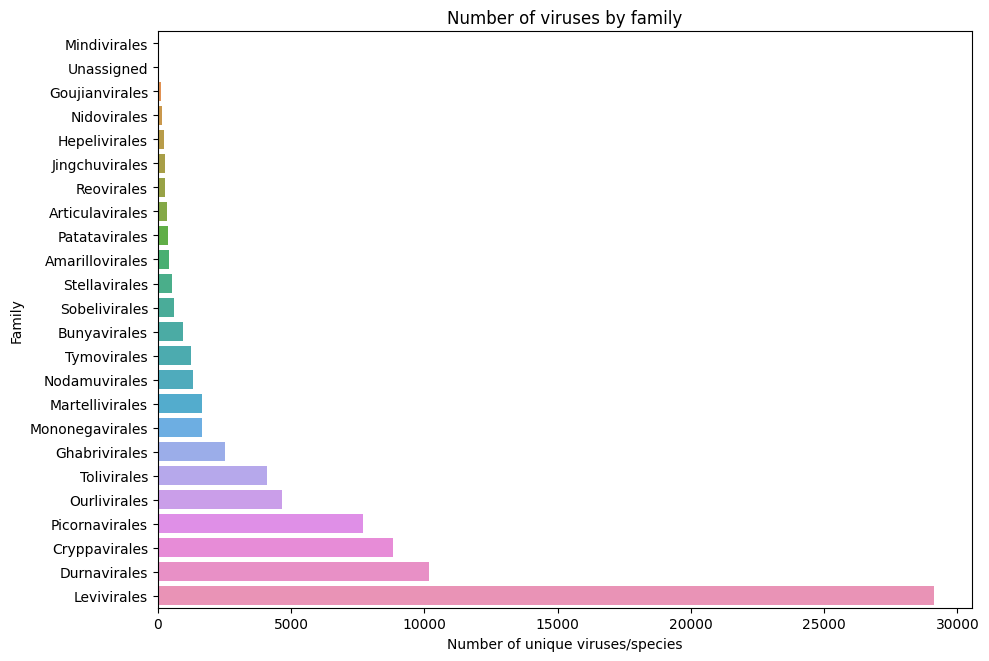

In [102]:
family_plot = family_counts.sort_values(
    "Number_of_viruses",
    ascending=True
)

plt.figure(
    figsize=(10, max(6, 0.28 * len(family_plot)))
)

sns.barplot(
    data=family_plot,
    x="Number_of_viruses",
    y="Family"
)

plt.xlabel("Number of unique viruses/species")
plt.ylabel("Family")
plt.title("Number of viruses by family")
plt.tight_layout()
plt.savefig('../figures/emma_vir_by_family.pdf')
plt.show()
plt.close()

In [94]:
order_counts = (
    emma_data
    .groupby("Order", dropna=False)["Species"]
    .nunique()
    .sort_values(ascending=False)
    .rename("Number_of_viruses")
    .reset_index()
)

order_counts

,Order,Number_of_viruses
0,Leviviridae,29108
1,Mitoviridae,8807
2,Picobirnaviridae,5124
3,Botourmiaviridae,4647
4,Partitiviridae,4109
...,...,...
68,Cystoviridae,16
69,Solinviviridae,15
70,Filoviridae,12
71,Tospoviridae,12


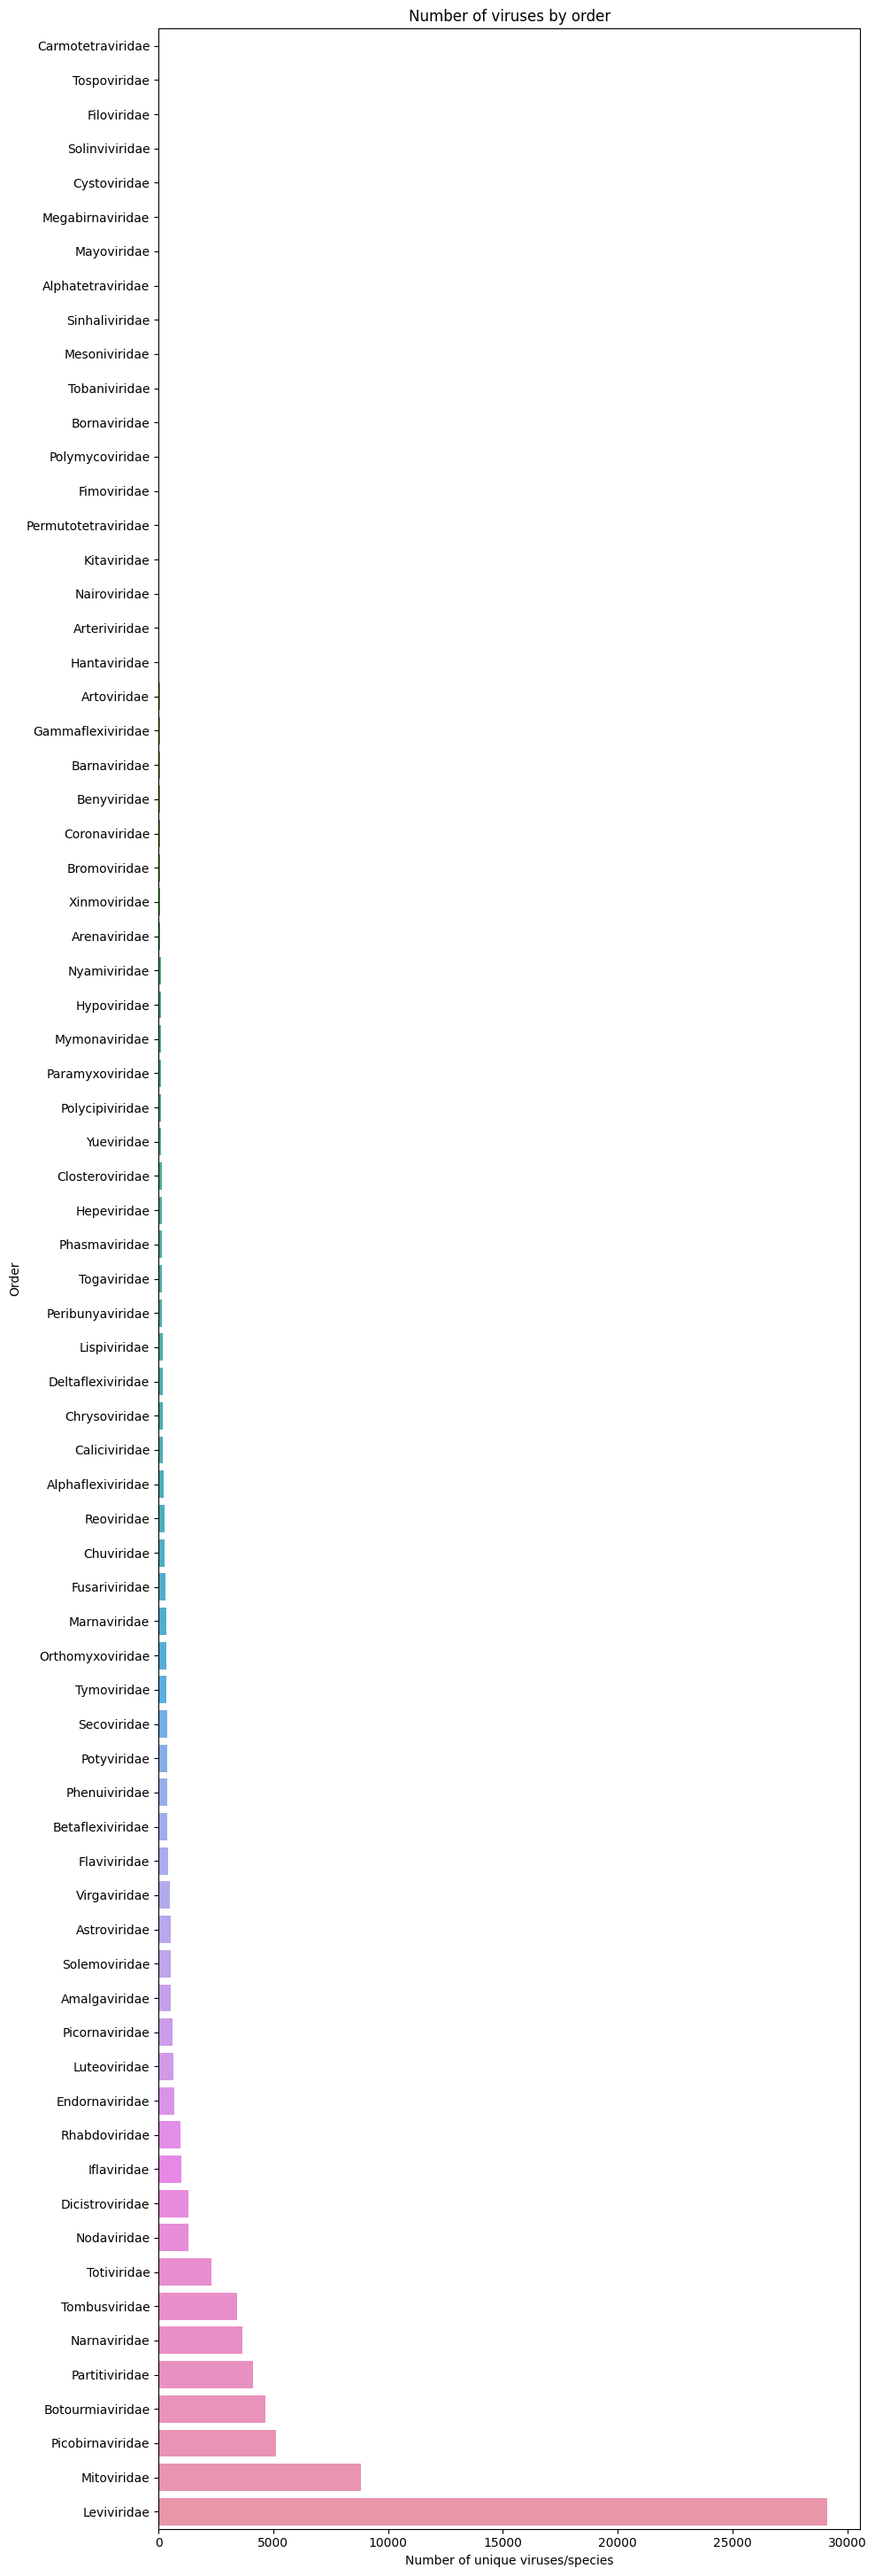

In [103]:
order_plot = order_counts.sort_values(
    "Number_of_viruses",
    ascending=True
)

plt.figure(
    figsize=(10, max(5, 0.4 * len(order_plot)))
)

sns.barplot(
    data=order_plot,
    x="Number_of_viruses",
    y="Order"
)

plt.xlabel("Number of unique viruses/species")
plt.ylabel("Order")
plt.title("Number of viruses by order")
plt.tight_layout()
plt.savefig('../figures/emma_vir_by_order.pdf')
plt.show()
plt.close()

In [96]:
strand_counts = (
    emma_data
    .groupby("Strand", observed=False)["Species"]
    .nunique()
    .reindex(strand_order)
    .rename("Number_of_viruses")
    .reset_index()
)

strand_counts["Percent"] = (
    100
    * strand_counts["Number_of_viruses"]
    / strand_counts["Number_of_viruses"].sum()
)

strand_counts.round(1)

,Strand,Number_of_viruses,Percent
0,ssRNA+,60793,78.7
1,ssRNA-,3826,5.0
2,dsRNA,12589,16.3


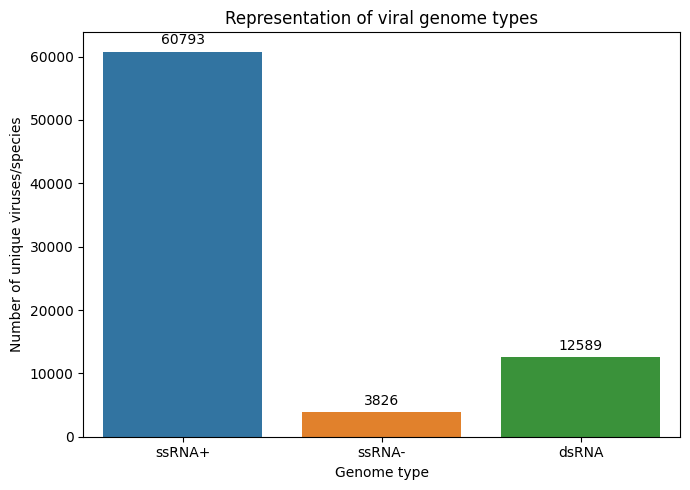

In [104]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=strand_counts,
    x="Strand",
    y="Number_of_viruses",
    order=strand_order
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.xlabel("Genome type")
plt.ylabel("Number of unique viruses/species")
plt.title("Representation of viral genome types")
plt.tight_layout()
plt.savefig('../figures/emma_vir_num_by_gentype.pdf')
plt.show()
plt.close()

In [98]:
family_strand_table = pd.crosstab(
    emma_data["Family"],
    emma_data["Strand"]
)

family_strand_table["Total"] = family_strand_table.sum(axis=1)

family_strand_table = family_strand_table.sort_values(
    "Total",
    ascending=False
)

family_strand_table.head(20)

Strand,dsRNA,ssRNA+,ssRNA-,Total
Family,,,,
Levivirales,0,29108,0,29108
Durnavirales,9770,417,0,10187
Cryppavirales,0,8807,0,8807
Picornavirales,0,7683,0,7683
Ourlivirales,0,4647,0,4647
Tolivirales,0,4090,0,4090
Ghabrivirales,2514,0,0,2514
Mononegavirales,0,0,1644,1644
Martellivirales,0,1641,0,1641


In [99]:
emma_data.to_csv('../data_obtain/emma_data_csv.csv')